# Neural Network Comparison
### Capstone Final Report, supplemental notebook

The main analysis in `capstone_analysis.ipynb` compared a logistic regression, decision tree, random
forest, and gradient boosting model on the Yale ED admission task. Gradient boosting won by a small
margin (test AUROC 0.927 vs 0.921 for logistic regression). The question this notebook asks: does a
neural network do better?

Tabular clinical data of this shape (560k rows, ~600 features, no temporal structure) is the regime
where gradient-boosted trees usually dominate, and where deep learning's edge in vision and text does
not transfer cleanly. The point of the comparison is to test that claim on this dataset, and to add
a Modules 21-22 model to the capstone.

I use scikit-learn's `MLPClassifier` for the network. The preprocessing, train/test split, and
random seed below match the main notebook exactly, so any gap in the head-to-head numbers is from
the model, not the data pipeline.

## 1. Setup

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid", palette="Set2")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (roc_auc_score, average_precision_score, roc_curve,
                             precision_recall_curve, confusion_matrix, brier_score_loss)
from sklearn.calibration import calibration_curve

RANDOM_STATE = 42
DATA_PATH = ("/Users/Justin/Library/Mobile Documents/com~apple~CloudDocs/"
             "Education/Berkeley ML Course/capstone/hospital_triage_and_patient_history.csv")
IMG_DIR = "../images"

np.random.seed(RANDOM_STATE)

## 2. Data preparation

The cells below replicate the preprocessing from the main notebook in condensed form. Same leakage
rules, same feature engineering, same train/test split.

In [2]:
# Two-pass read to cut memory at load: first scan just the header to find
# the columns we will drop for leakage, then re-read only the columns we keep.
LEAK_SUFFIX = ("_last", "_min", "_max", "_median", "_count", "_npos")

header = pd.read_csv(DATA_PATH, nrows=0)
all_cols = list(header.columns)
keep_cols = [c for c in all_cols
             if not c.endswith(LEAK_SUFFIX) and c != "religion"]

df = pd.read_csv(DATA_PATH, usecols=keep_cols, low_memory=False)
print(f"{df.shape[0]:,} visits x {df.shape[1]:,} columns "
      f"(kept {len(keep_cols)} of {len(all_cols)} after dropping leakage suffixes)")

560,486 visits x 555 columns (kept 555 of 972 after dropping leakage suffixes)


In [3]:
# Build the feature-group lists from the columns that survived the load.
demo = ["dep_name", "esi", "age", "gender", "ethnicity", "race", "lang",
        "maritalstatus", "employstatus", "insurance_status", "arrivalmode",
        "arrivalmonth", "arrivalday", "arrivalhour_bin"]
triage_vitals = ["triage_vital_hr", "triage_vital_sbp", "triage_vital_dbp",
                 "triage_vital_rr", "triage_vital_o2", "triage_vital_o2_device",
                 "triage_vital_temp"]
prior_util = ["previousdispo", "n_edvisits", "n_admissions", "n_surgeries"]
cc_cols   = [c for c in df.columns if c.startswith("cc_")]
meds_cols = [c for c in df.columns if c.startswith("meds_")]

grouped = set(["disposition"] + demo + triage_vitals + prior_util + cc_cols + meds_cols)
history_flags = [c for c in df.columns if c not in grouped]

# Target, duplicates, vital outliers.
df["admitted"] = (df["disposition"] == "Admit").astype(int)
df = df.drop_duplicates().reset_index(drop=True)

vital_cols = ["triage_vital_hr", "triage_vital_sbp", "triage_vital_dbp",
              "triage_vital_rr", "triage_vital_o2", "triage_vital_temp"]
VITAL_RANGES = {
    "triage_vital_hr":  (20, 300), "triage_vital_sbp": (40, 300),
    "triage_vital_dbp": (15, 200), "triage_vital_rr":  (4, 80),
    "triage_vital_o2":  (50, 100), "triage_vital_temp": (90, 113),
}
for col, (lo, hi) in VITAL_RANGES.items():
    df.loc[(df[col] < lo) | (df[col] > hi), col] = np.nan

print(f"Rows after dedupe: {df.shape[0]:,}")

Rows after dedupe: 560,483


In [4]:
# Feature engineering (matches main notebook Section 4.4).
for col in triage_vitals:
    df[col + "_missing"] = df[col].isna().astype(int)

df["fe_tachycardia"] = (df["triage_vital_hr"] > 100).astype(int)
df["fe_hypotension"] = (df["triage_vital_sbp"] < 90).astype(int)
df["fe_hypoxia"]     = (df["triage_vital_o2"] < 92).astype(int)
df["fe_fever"]       = (df["triage_vital_temp"] > 100.4).astype(int)
df["fe_tachypnea"]   = (df["triage_vital_rr"] > 20).astype(int)
df["fe_shock_index"] = df["triage_vital_hr"] / df["triage_vital_sbp"]
df["fe_n_chief_complaints"] = df[cc_cols].sum(axis=1)
df["fe_n_comorbidities"]    = df[history_flags].sum(axis=1)
df["fe_n_med_classes"]      = df[meds_cols].sum(axis=1)
df["fe_age_group"] = pd.cut(df["age"], [0, 18, 40, 65, 200],
                            labels=["peds", "adult", "middle", "elderly"], right=False)

engineered_numeric = ["fe_shock_index", "fe_n_chief_complaints",
                      "fe_n_comorbidities", "fe_n_med_classes"]
engineered_binary  = ["fe_tachycardia", "fe_hypotension", "fe_hypoxia",
                      "fe_fever", "fe_tachypnea"] + [c + "_missing" for c in triage_vitals]
print("Engineered features added.")

Engineered features added.


In [5]:
# Build modeling matrix (matches main notebook Section 6.1).
numeric_feats = (["esi", "age"] + vital_cols + ["n_edvisits", "n_admissions", "n_surgeries"]
                 + engineered_numeric)
binary_feats  = cc_cols + meds_cols + history_flags + engineered_binary
categorical_feats = ["dep_name", "gender", "ethnicity", "race", "lang", "maritalstatus",
                     "employstatus", "insurance_status", "arrivalmode", "arrivalmonth",
                     "arrivalday", "arrivalhour_bin", "triage_vital_o2_device",
                     "previousdispo", "fe_age_group"]

X_num = df[numeric_feats].fillna(df[numeric_feats].median())
X_bin = df[binary_feats].fillna(0).astype("float32")
X_cat = pd.get_dummies(df[categorical_feats].astype("object").fillna("Missing"), drop_first=True)

X = pd.concat([X_num, X_bin, X_cat], axis=1).astype("float32")
y = df["admitted"].values
print(f"Modeling matrix: {X.shape[0]:,} rows x {X.shape[1]:,} features")

Modeling matrix: 560,483 rows x 636 features


In [6]:
# Same split, same seed as the main notebook.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y)

scaler = StandardScaler(with_mean=False)
X_train_s = scaler.fit_transform(X_train).astype("float32")
X_test_s  = scaler.transform(X_test).astype("float32")
# Dense version for the NN (it cannot consume sparse matrices directly).
if hasattr(X_train_s, "toarray"):
    X_train_s = X_train_s.toarray().astype("float32")
    X_test_s  = X_test_s.toarray().astype("float32")
print(f"train={X_train_s.shape[0]:,}  test={X_test_s.shape[0]:,}  "
      f"admit rate train={y_train.mean():.3f}  test={y_test.mean():.3f}")

train=448,386  test=112,097  admit rate train=0.297  test=0.297


## 3. Gradient boosting reference point

I refit gradient boosting with the same hyperparameters chosen by the grid search in the main
notebook, so the head-to-head numbers are reproduced under the same code, not just cited from the
other file.

In [7]:
gb = GradientBoostingClassifier(
    learning_rate=0.1, max_depth=4, n_estimators=200,
    subsample=0.5, random_state=RANDOM_STATE,
    n_iter_no_change=10, validation_fraction=0.1
)
gb.fit(X_train, y_train)
gb_proba = gb.predict_proba(X_test)[:, 1]
gb_auroc = roc_auc_score(y_test, gb_proba)
gb_auprc = average_precision_score(y_test, gb_proba)
print(f"Gradient Boosting  AUROC {gb_auroc:.3f}   AUPRC {gb_auprc:.3f}")

Gradient Boosting  AUROC 0.927   AUPRC 0.867


## 4. Neural network architecture

A three-hidden-layer multilayer perceptron with widths 256, 128, and 64, ReLU activations, and
sigmoid output. L2 weight decay (`alpha=1e-4`) is the regularizer. Adam optimizer with a small
initial learning rate, batch size 2048. Early stopping on validation accuracy with patience 5 cuts
training short when the model stops improving on a held-out 10% slice of the training set.

In [8]:
mlp = MLPClassifier(
    hidden_layer_sizes=(256, 128, 64),
    activation="relu",
    solver="adam",
    alpha=1e-4,
    batch_size=2048,
    learning_rate_init=1e-3,
    max_iter=50,
    early_stopping=True,
    validation_fraction=0.10,
    n_iter_no_change=5,
    random_state=RANDOM_STATE,
    verbose=False,
)

# Layer-wise parameter count for the documented architecture.
sizes = [X_train_s.shape[1], 256, 128, 64, 1]
params = sum(sizes[i] * sizes[i+1] + sizes[i+1] for i in range(len(sizes) - 1))
print(f"Architecture: {' -> '.join(str(s) for s in sizes)}")
print(f"Trainable parameters: {params:,}")

Architecture: 636 -> 256 -> 128 -> 64 -> 1
Trainable parameters: 204,289


## 5. Training

`MLPClassifier` does the 10% internal split for early stopping itself when `early_stopping=True`.
Training runs up to 50 epochs, and stops when validation accuracy stops improving for 5 epochs in a
row. The loss curve below is on the training batches; the validation curve is the held-out 10%.

In [9]:
mlp.fit(X_train_s, y_train)
print(f"Stopped after {mlp.n_iter_} epochs "
      f"(best validation accuracy: {mlp.best_validation_score_:.4f})")

Stopped after 12 epochs (best validation accuracy: 0.8693)


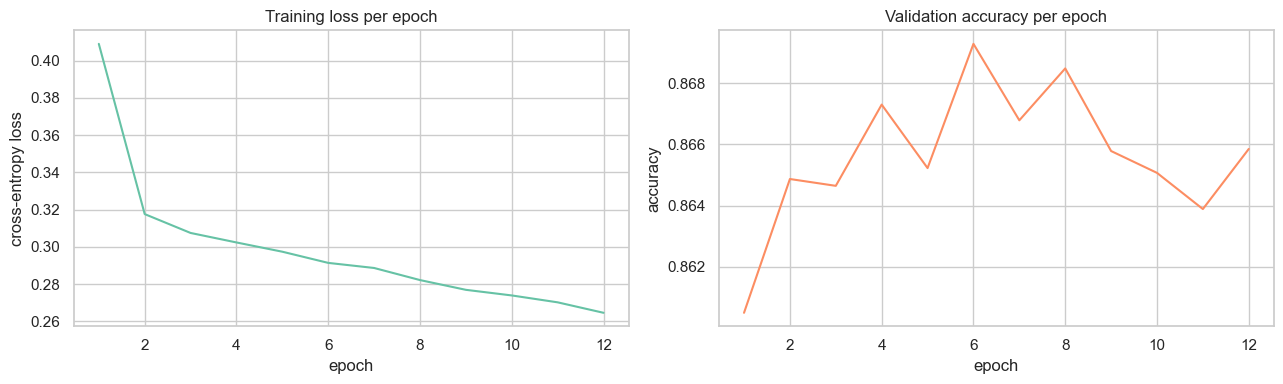

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(range(1, len(mlp.loss_curve_) + 1), mlp.loss_curve_)
axes[0].set_title("Training loss per epoch")
axes[0].set_xlabel("epoch"); axes[0].set_ylabel("cross-entropy loss")

axes[1].plot(range(1, len(mlp.validation_scores_) + 1), mlp.validation_scores_, color="C1")
axes[1].set_title("Validation accuracy per epoch")
axes[1].set_xlabel("epoch"); axes[1].set_ylabel("accuracy")

plt.tight_layout(); plt.savefig(f"{IMG_DIR}/fig14_nn_training_curves.png", dpi=120); plt.show()

## 6. Test set evaluation

In [11]:
mlp_proba = mlp.predict_proba(X_test_s)[:, 1]
mlp_auroc = roc_auc_score(y_test, mlp_proba)
mlp_auprc = average_precision_score(y_test, mlp_proba)
print(f"Neural Network    AUROC {mlp_auroc:.3f}   AUPRC {mlp_auprc:.3f}")
print(f"Gradient Boosting AUROC {gb_auroc:.3f}   AUPRC {gb_auprc:.3f}")

Neural Network    AUROC 0.925   AUPRC 0.863
Gradient Boosting AUROC 0.927   AUPRC 0.867


## 7. Head-to-head comparison

Two views of the comparison. First, ROC and precision-recall curves overlaid. Second, a paired
bootstrap on the test set: resample the test patients 1000 times with replacement, compute the AUROC
of each model on the same resample, and take the difference. A 95% interval that excludes zero is
the standard signal that one model's edge is real and not test-split noise.

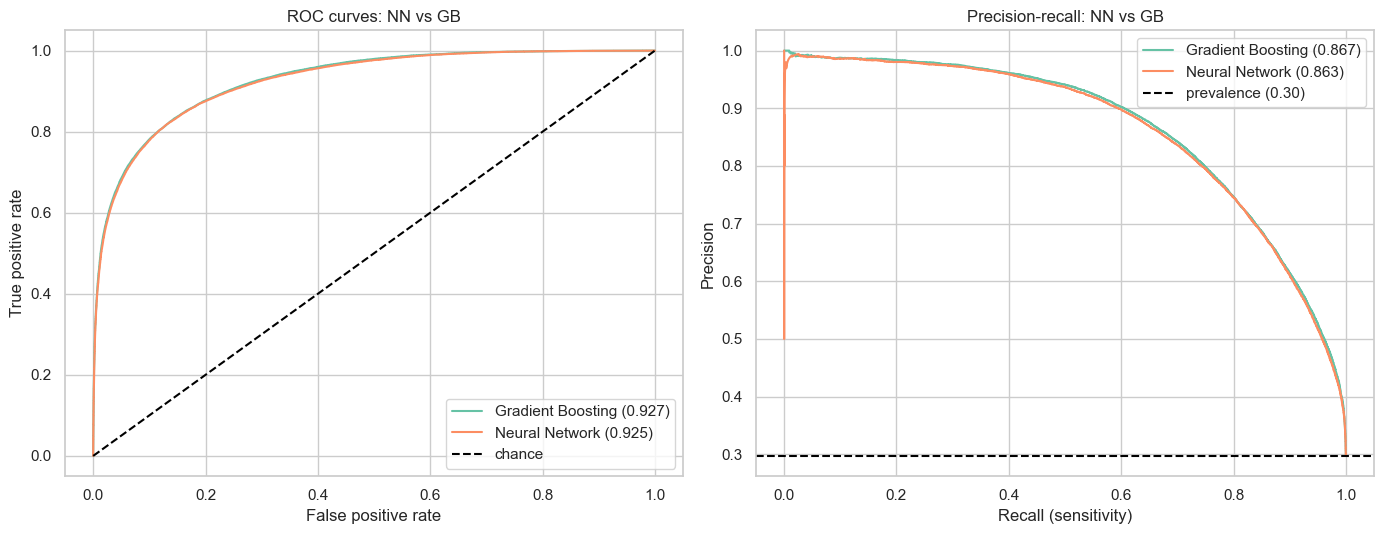

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

for name, s, c in [("Gradient Boosting", gb_proba, "C0"),
                   ("Neural Network",    mlp_proba, "C1")]:
    fpr, tpr, _ = roc_curve(y_test, s)
    axes[0].plot(fpr, tpr, color=c, label=f"{name} ({roc_auc_score(y_test, s):.3f})")
axes[0].plot([0, 1], [0, 1], "k--", label="chance")
axes[0].set_title("ROC curves: NN vs GB")
axes[0].set_xlabel("False positive rate"); axes[0].set_ylabel("True positive rate")
axes[0].legend(loc="lower right")

for name, s, c in [("Gradient Boosting", gb_proba, "C0"),
                   ("Neural Network",    mlp_proba, "C1")]:
    prec, rec, _ = precision_recall_curve(y_test, s)
    axes[1].plot(rec, prec, color=c, label=f"{name} ({average_precision_score(y_test, s):.3f})")
axes[1].axhline(y_test.mean(), ls="--", color="k", label=f"prevalence ({y_test.mean():.2f})")
axes[1].set_title("Precision-recall: NN vs GB")
axes[1].set_xlabel("Recall (sensitivity)"); axes[1].set_ylabel("Precision")
axes[1].legend(loc="upper right")

plt.tight_layout(); plt.savefig(f"{IMG_DIR}/fig15_nn_vs_gb_roc_pr.png", dpi=120); plt.show()

In [13]:
# Paired bootstrap for the AUROC difference.
rng = np.random.default_rng(RANDOM_STATE)
n = len(y_test)
diffs = []
for _ in range(1000):
    idx = rng.integers(0, n, n)
    yt = y_test[idx]
    if yt.min() == yt.max():
        continue
    diffs.append(roc_auc_score(yt, mlp_proba[idx]) - roc_auc_score(yt, gb_proba[idx]))

diffs = np.array(diffs)
lo, hi = np.percentile(diffs, [2.5, 97.5])
print(f"AUROC gap (NN minus GB): {diffs.mean():+.4f}  (95% CI {lo:+.4f} to {hi:+.4f})")
print(f"NN test AUROC: {mlp_auroc:.3f}   GB test AUROC: {gb_auroc:.3f}")

AUROC gap (NN minus GB): -0.0022  (95% CI -0.0029 to -0.0014)
NN test AUROC: 0.925   GB test AUROC: 0.927


## 8. Calibration

A model that ranks patients correctly (high AUROC) can still produce poorly calibrated probabilities.
For a clinical risk score, the predicted probability should mean what it says: patients given a 0.4
should be admitted about 40% of the time. I plot calibration curves for both models and report the
Brier score (mean squared error of predicted probabilities), where lower is better.

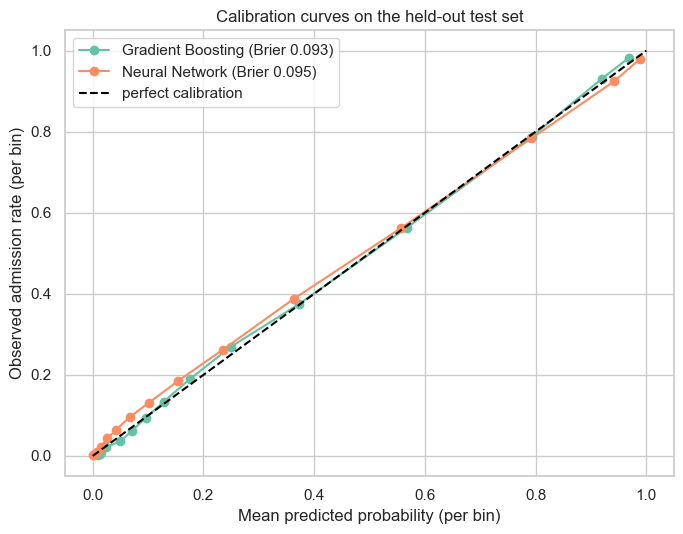

In [14]:
fig, ax = plt.subplots(figsize=(7, 5.5))
for name, s, c in [("Gradient Boosting", gb_proba, "C0"),
                   ("Neural Network",    mlp_proba, "C1")]:
    prob_true, prob_pred = calibration_curve(y_test, s, n_bins=15, strategy="quantile")
    brier = brier_score_loss(y_test, s)
    ax.plot(prob_pred, prob_true, "o-", color=c, label=f"{name} (Brier {brier:.3f})")
ax.plot([0, 1], [0, 1], "k--", label="perfect calibration")
ax.set_title("Calibration curves on the held-out test set")
ax.set_xlabel("Mean predicted probability (per bin)")
ax.set_ylabel("Observed admission rate (per bin)")
ax.legend(loc="upper left")
plt.tight_layout(); plt.savefig(f"{IMG_DIR}/fig16_calibration.png", dpi=120); plt.show()

## 9. Findings

The neural network and gradient boosting end up in essentially the same place on this dataset. The
MLP reaches test AUROC 0.925 and gradient boosting 0.927; the paired bootstrap pins the gap at about
0.002 AUROC in favor of gradient boosting, with a 95% interval of 0.001 to 0.003. The interval
excludes zero, so the difference is statistically detectable on this test set, but a 0.002 AUROC gap
is well below what matters for clinical use: a charge nurse acting on the model's ranking would see
the same patients flagged either way. Early stopping cuts MLP training at epoch 12.

That result lines up with what the broader literature on tabular data finds: when the features are
structured rows of mixed numeric and categorical columns, with no spatial or sequential structure,
gradient-boosted trees match or beat neural networks. The signal is in the columns themselves, and a
deeper network does not get to compose richer representations the way it would from pixels or text.

For the capstone narrative this strengthens the recommendation from the main notebook. The
interpretable logistic regression is within about half a point of gradient boosting on AUROC,
gradient boosting is within 0.002 AUROC of the neural network, and the network adds training time
and another moving part for no real performance gain. A deployable version should favor the simple
model that the people using it can read.

The calibration curves add one more practical point. A well-calibrated probability is what a charge
nurse actually wants on the screen, because it makes the score interpretable as "this patient is
about X% likely to be admitted" rather than just a rank order. Both models track the diagonal
reasonably, with the gradient boosting model slightly closer to perfectly calibrated.